# Use the outlier method for preprocessing

## Single-sample analysis

In [1]:
# basically I will analyse one sample to explain what steps I took in the multi-sample analysis.

In [2]:
import spatools as st
import scanpy as sc
import os

adata = st.read("/mnt/SATA/spatialCourse/data/FB_P1_S2.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 1905 × 21395
    obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial'

In [4]:
from copy import deepcopy
adata_raw = deepcopy(adata)

In [5]:

import warnings
import numpy as np
from anndata import AnnData
from anndata._core.anndata import ImplicitModificationWarning

def is_outlier(x, 
               k: float = 4, 
               method='both'
               ) -> np.ndarray:
    """
    Identify outliers in an array of values using Median Absolute Deviation (MAD).

    Parameters
    ----------
    x : array-like
        Input array of values.
    k : int, optional
        The number of median absolute deviations from the median to consider a value
        an outlier. Default is 4.
    method : str, optional
        Method to identify outliers:
        - 'high': identify only high outliers (values above median + k*MAD)
        - 'low': identify only low outliers (values below median - k*MAD)  
        - 'both': identify both high and low outliers (default)

    Returns
    -------
    boolean array
        Boolean array indicating which values are outliers.

    Notes
    -----
    This function uses the Median Absolute Deviation (MAD) to identify outliers.
    The MAD is a robust measure of the spread of the data, and outliers are defined
    as values that are more than k times the MAD away from the median.
    
    Examples
    --------
    >>> data = [1, 2, 3, 4, 5, 100]  # 100 is a high outlier
    >>> is_outlier(data, method='high')
    array([False, False, False, False, False, True])
    
    >>> data = [-100, 2, 3, 4, 5, 6]  # -100 is a low outlier
    >>> is_outlier(data, method='low') 
    array([True, False, False, False, False, False])
    
    >>> data = [-100, 2, 3, 4, 5, 100]  # both -100 and 100 are outliers
    >>> is_outlier(data, method='both')
    array([True, False, False, False, False, True])
    """
    x = np.asarray(x)

    median = np.median(x)
    deviation = x - median
    mad = np.median(np.abs(deviation))

    if mad == 0:
        return np.zeros_like(x, dtype=bool)

    threshold = k * mad

    conditions = {
        "high": deviation > threshold,
        "low": deviation < -threshold,
        "both": np.abs(deviation) > threshold,
    }

    try:
        return conditions[method]
    except KeyError:
        raise ValueError("method must be 'high', 'low', or 'both'")

def save_spatial_files(output_dir: str, 
                       adatas_dict: dict
                       ):
    # supress irrelevant warning
    warnings.filterwarnings("ignore", message="Trying to modify attribute", category=ImplicitModificationWarning)
    # Verifica se o diretório de saída existe, se não, cria
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for name, adata in adatas_dict.items():
        if name.endswith('.h5ad'):
            output_file_path = os.path.join(output_dir, name)
        else:
            output_file_path = os.path.join(output_dir, f"{name}.h5ad")
        sc.write(output_file_path, adata) #type: ignore

def anndataFilters(
    adata: AnnData,
    counts_outliers: bool = False,
    genes_outliers: bool = False,
    genes_and_counts_outliers: bool = False,
    mt_percentage_outliers: bool = False,
    k: float = 4
) -> AnnData:

    adata = adata.copy()

    stats = {
        "initial_n_spots": adata.n_obs,
        "initial_n_genes": adata.n_vars
    }

    # --- definição dos filtros ---
    filters = []

    if genes_and_counts_outliers:
        filters.append(("combined", lambda ad: ~(
            is_outlier(x = ad.obs['log1p_total_counts'], 
                       method = "low", 
                       k = k
                       ) |
            is_outlier(x = ad.obs['log1p_n_genes_by_counts'], 
                       method = "low", 
                       k = k
                       )
        )))

    else:
        if counts_outliers:
            filters.append(("counts", lambda ad: ~is_outlier(x = ad.obs['log1p_total_counts'], 
                                                             method = "low", 
                                                             k = k
                                                             )))

        if genes_outliers:
            filters.append(("genes", lambda ad: ~is_outlier(x = ad.obs['log1p_n_genes_by_counts'], 
                                                            method = "low", 
                                                            k = k
                                                            )))

    if mt_percentage_outliers:
        filters.append(("mt", lambda ad: ~is_outlier(x = ad.obs["pct_counts_mt"], 
                                                     method = "high", 
                                                     k = k
                                                     )))

    # --- aplicar filtros ---
    for name, func in filters:
        mask = func(adata)
        adata = adata[mask].copy()
        stats[f"n_after_{name}_filter"] = adata.n_obs

    # --- genes ---
    sc.pp.filter_genes(adata, min_cells=1)

    stats["final_n_spots"] = adata.n_obs
    stats["final_n_genes"] = adata.n_vars

    adata.uns["preprocessing_stats"] = stats

    return adata

def preprocessing(adata: AnnData, 
                 output_dir: str = "",
                 save_files: bool = False, 
                 genes_outliers: bool = False, 
                 counts_outliers: bool = False,
                 mt_percentage_outliers: bool = True,
                 genes_and_counts_outliers: bool = True,
                 k: float = 4):
    """
    Preprocess a single Visium AnnData object and store stats in .uns.
    """

    # --- validações ---
    if genes_and_counts_outliers and (genes_outliers or counts_outliers):
        raise ValueError("Use combined filter OR individual filters, not both.")

    if genes_outliers and counts_outliers:
        raise ValueError("Use combined filter instead of separate filters.")

    if save_files and not output_dir:
        raise ValueError("output_dir must be defined to save files.")

    adata = adata.copy()

    adata.var_names_make_unique()

    # --- MT genes ---
    mt_mask = adata.var_names.str.startswith("MT-")
    if "gene_ids" in adata.var.columns:
        mt_mask |= adata.var["gene_ids"].str.startswith("MT-", na=False)

    adata.var["mt"] = mt_mask

    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

    adata = anndataFilters(adata, 
                   counts_outliers=counts_outliers, 
                   genes_outliers=genes_outliers,
                   genes_and_counts_outliers=genes_and_counts_outliers,
                   mt_percentage_outliers=mt_percentage_outliers,
                   k = k)

    # --- salvar ---
    if save_files:
        os.makedirs(output_dir, exist_ok=True)
        save_spatial_files(output_dir, adata)

    return adata

In [6]:
adata = preprocessing(
        adata,
        genes_and_counts_outliers=True,
        mt_percentage_outliers=True)

In [7]:
print(f"Número de celulas antes {adata_raw.n_obs}, numero de genes antes {adata_raw.n_vars}")

print(f"Número de celulas depois {adata.n_obs}, numero de genes depois {adata.n_vars}")
print(1 - adata.n_obs / adata_raw.n_obs)

Número de celulas antes 1905, numero de genes antes 21395
Número de celulas depois 1850, numero de genes depois 21381
0.02887139107611547


In [8]:
adata

AnnData object with n_obs × n_vars = 1850 × 21381
    obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial', 'preprocessing_stats'
    obsm: 'spatial'

In [17]:
sc.write("/mnt/SATA/spatialCourse/output/singleSpatial.h5ad", adata)

In [9]:
del adata 
del adata_raw

## Multi-sample analysis

In [23]:
import spatools as st
import scanpy as sc
import os

adatas: dict = st.read("/mnt/SATA/spatialCourse/data")

🔎 Analisando diretório: /mnt/SATA/spatialCourse/data
  ➜ Processando: 'FB_P1_S2.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'FB_P26_S4.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'UB_P10_S2.h5ad' ... ✅ Lido como [H5AD]
  ➜ Processando: 'UB_P25_S4.h5ad' ... ✅ Lido como [H5AD]


In [24]:
from copy import deepcopy
adatas_raw = deepcopy(adatas)

In [25]:
adatas

{'FB_P1_S2': AnnData object with n_obs × n_vars = 1905 × 21395
     obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
     var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'spatial'
     obsm: 'spatial',
 'FB_P26_S4': AnnData object with n_obs × n_vars = 3504 × 22834
     obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'selected_area'
     var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
     uns: 'spatial'
     obsm: 'spatial',
 'UB_P10_S2': AnnData object with n_obs × n_vars = 2719 × 22589
     obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_co

In [ ]:
import spatools as st

adatas = st.pp.Preprocessing.run("MAD_combined", adatas_dict=adatas) # TODO change k value in your analysis
# html ___

In [28]:
print(f"Número de celulas antes {sum([adatas_raw[i].n_obs for i in adatas])}, numero de genes antes {sum([adatas_raw[i].n_vars for i in adatas])}")

print(f"Número de celulas depois {sum([adatas[i].n_obs for i in adatas])}, numero de genes depois {sum([adatas[i].n_vars for i in adatas])}")
print(1-sum([adatas[i].n_obs for i in adatas])/sum([adatas_raw[i].n_obs for i in adatas]))
del adatas_raw

Número de celulas antes 11852, numero de genes antes 91306
Número de celulas depois 11219, numero de genes depois 91060
0.05340870739115766


In [29]:
adatas

{'FB_P1_S2': AnnData object with n_obs × n_vars = 1850 × 21381
     obs: 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
     var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'spatial', 'preprocessing_stats_FB_P1_S2'
     obsm: 'spatial',
 'FB_P26_S4': AnnData object with n_obs × n_vars = 3218 × 22680
     obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'selected_area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt

In [30]:
len(adatas)

4

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/spatools/plotting/pl.py:1236: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prev_val = step_sums[i-1]


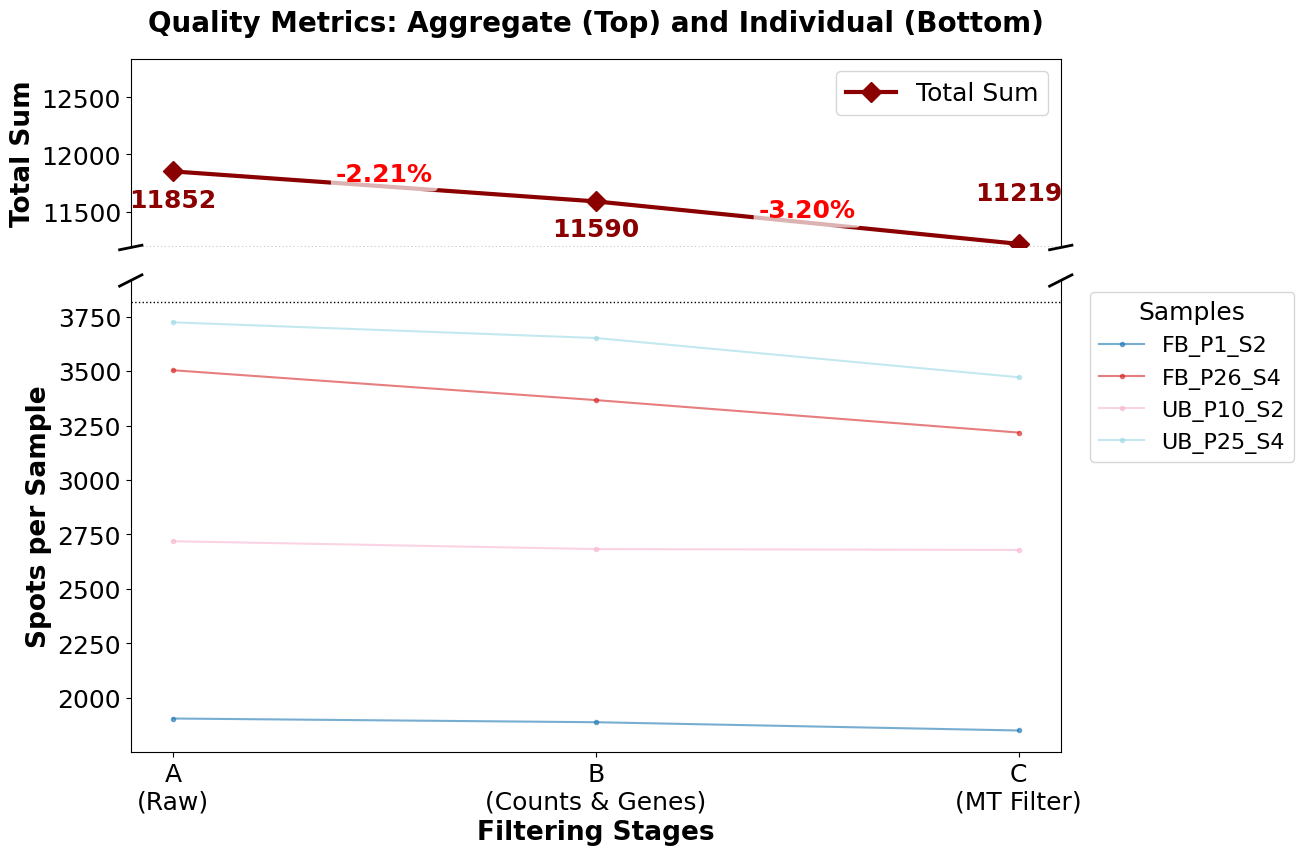

,Raw,Counts&Genes,MT
FB_P1_S2,1905,1888,1850
FB_P26_S4,3504,3367,3218
UB_P10_S2,2719,2683,2679
UB_P25_S4,3724,3652,3472


In [31]:
st.pl.preprocessing_quality_metrics(adatas=adatas, dodge=0.03)

In [32]:
output_dir = "/mnt/SATA/spatialCourse/output"

for name, adata in adatas.items():
    if name.endswith(".h5ad"):
        output_file_path = os.path.join(output_dir, name)
    else:
        output_file_path = os.path.join(output_dir, f"{name}.h5ad")

    sc.write(output_file_path, adata)  # type: ignore

## Vizualizacao do dado anterior ao pre-processamento

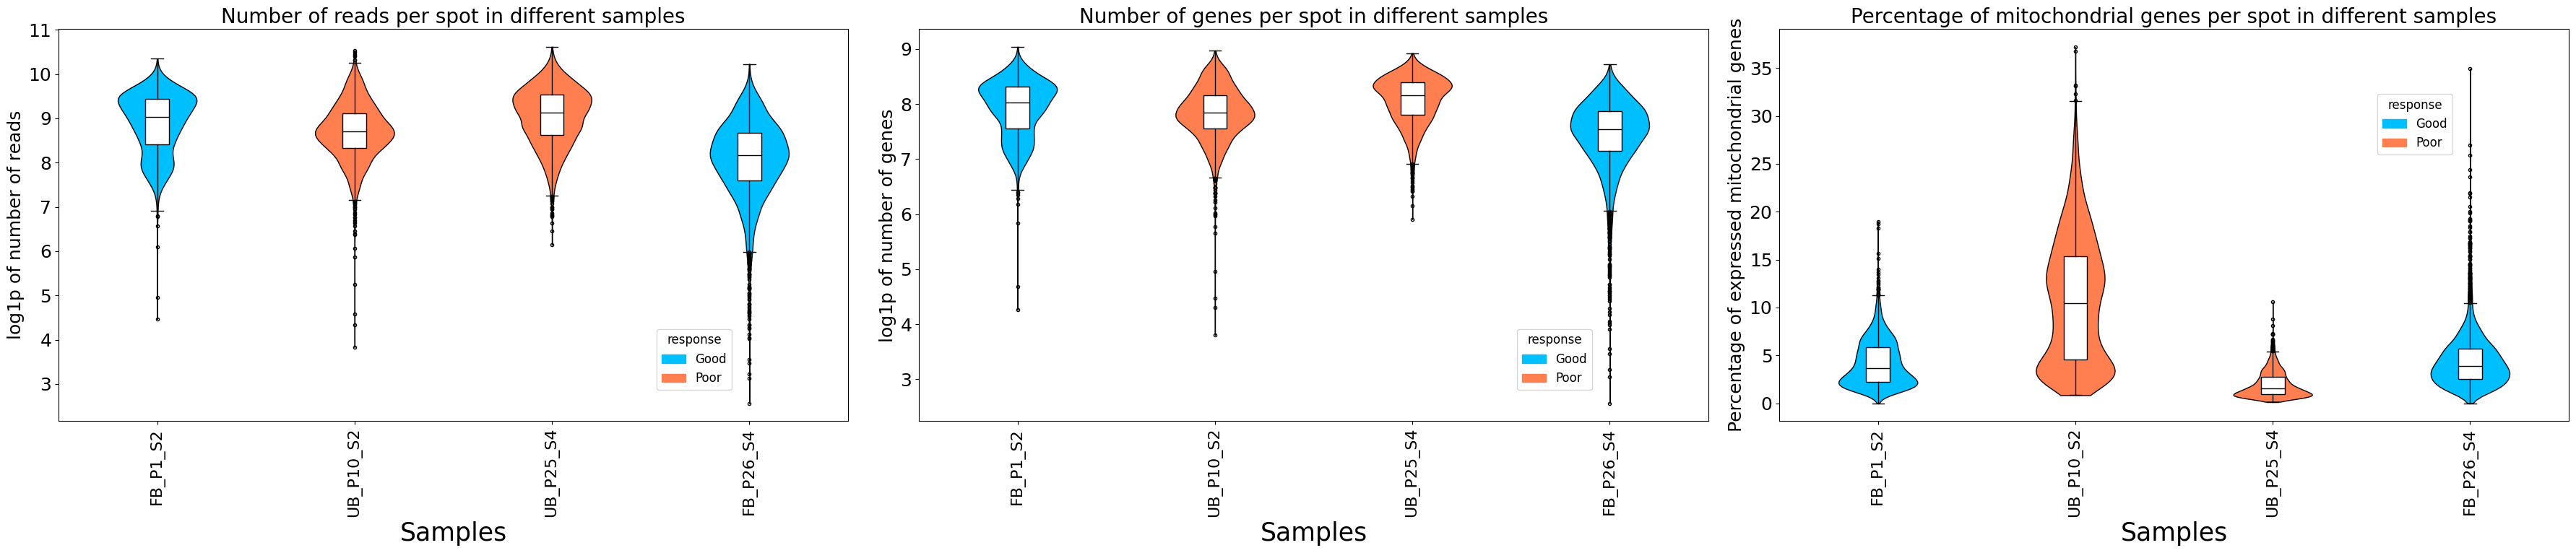

In [33]:
import matplotlib.pyplot as plt
# Define the parameters for the plots
plot_configs = [
    {
        "clusters_col": "log1p_total_counts",
        "title": "Number of reads per spot in different samples",
        "ylabel": "log1p of number of reads",
        "legend_pos": (0.75, 0.25)
    },
    {
        "clusters_col": "log1p_n_genes_by_counts",
        "title": "Number of genes per spot in different samples",
        "ylabel": "log1p of number of genes",
        "legend_pos": (0.75, 0.25)
    },
    {
        "clusters_col": "pct_counts_mt",
        "title": "Percentage of mitochondrial genes per spot in different samples",
        "ylabel": "Percentage of expressed mitochondrial genes",
        "legend_pos": (0.75, 0.85)
    }
]

# Create subplots
fig, axes = plt.subplots(1, len(plot_configs), figsize=(12 * len(plot_configs), 8))

# Ensure axes is always iterable
if len(plot_configs) == 1:
    axes = [axes]

classification_dict = {
    "FB": ["Good", 'deepskyblue'],
    "UB": ["Poor", 'coral']
}

# Iterate over the configurations and plot each
for ax, config in zip(axes, plot_configs):
    st.pl.outlier_quality(
        path_to_directory=fr"/mnt/SATA/spatialCourse/data",
        clusters_col=config["clusters_col"],
        group_by="response",
        outlier=None,
        add_line=False,
        add_outliers=False,
        legend1_pos=config["legend_pos"],
        title=config["title"],
        ylabel=config["ylabel"],
        xlabel="Samples",
        ax=ax,  # Explicitly pass the axis to the function
        show = False,  # Prevent the function from calling plt.show()
        **classification_dict
    )

plt.tight_layout()
plt.show()

## Vizualizacao do dado pos pré-processado

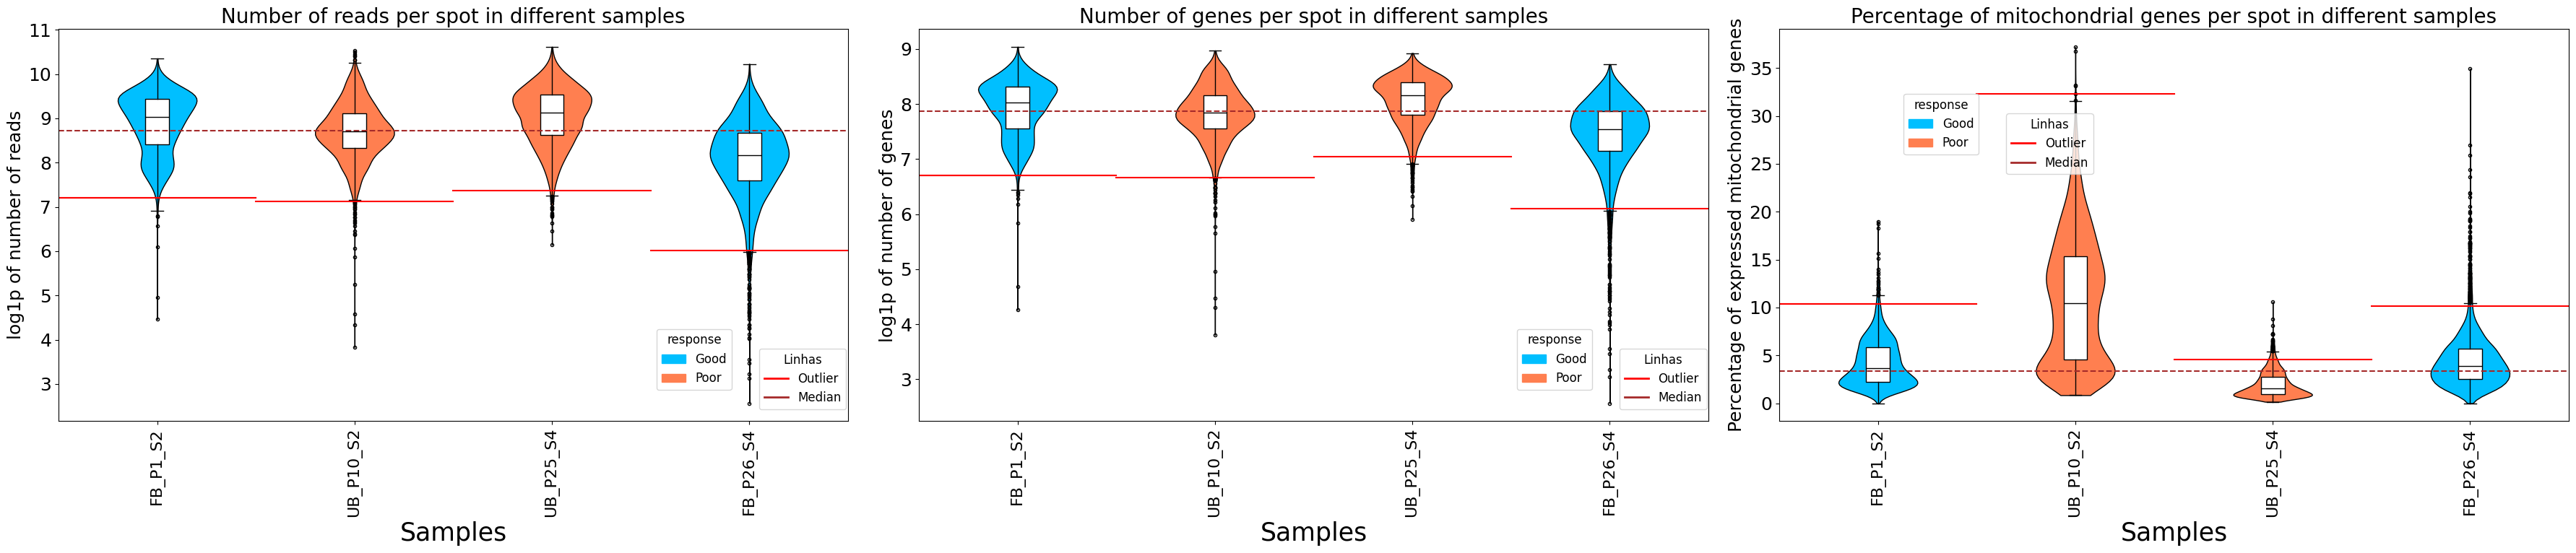

In [37]:
import matplotlib.pyplot as plt
import spatools as st


# Define the parameters for the plots
plot_configs = [
    {
        "clusters_col": "log1p_total_counts",
        "title": "Number of reads per spot in different samples",
        "ylabel": "log1p of number of reads",
        "legend_pos1": (0.75, 0.25),
        "legend_pos2": (0.88, 0.20),
        "outlier_type": "lower"
    },
    {
        "clusters_col": "log1p_n_genes_by_counts",
        "title": "Number of genes per spot in different samples",
        "ylabel": "log1p of number of genes",
        "legend_pos1": (0.75, 0.25),
        "legend_pos2": (0.88, 0.20),
        "outlier_type": "lower"
    },
    {
        "clusters_col": "pct_counts_mt",
        "title": "Percentage of mitochondrial genes per spot in different samples",
        "ylabel": "Percentage of expressed mitochondrial genes",
        "legend_pos1": (0.15, 0.85), # TODO
        "legend_pos2": (0.28, 0.80), # TODO
        "outlier_type": "upper"
    }
]

# Create subplots
fig, axes = plt.subplots(1, len(plot_configs), figsize=(12 * len(plot_configs), 8))

# Ensure axes is always iterable
if len(plot_configs) == 1:
    axes = [axes]

classification_dict = {
    "FB": ["Good", 'deepskyblue'],
    "UB": ["Poor", 'coral']
}

# Iterate over the configurations and plot each
for ax, config in zip(axes, plot_configs):
    st.pl.outlier_quality(
        path_to_directory=fr"/mnt/SATA/spatialCourse/data",
        clusters_col=config["clusters_col"],
        group_by="response",
        outlier=4,
        outlier_type=config["outlier_type"],
        add_line=True,
        add_outliers=True,
        legend1_pos=config["legend_pos1"],
        legend2_pos=config["legend_pos2"],
        title=config["title"],
        ylabel=config["ylabel"],
        xlabel="Samples",
        ax=ax,  # Explicitly pass the axis to the function
        show = False,  # Prevent the function from calling plt.show()
        **classification_dict
    )

plt.tight_layout()
plt.show()